# Salary Prediction model 

# Importing libraries

In [2]:
#Loading......
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Just look at data

In [3]:
var = pd.read_csv('Salary_Data.csv')
var.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


# Let know more about this data

In [4]:
var.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


## Column name

In [5]:
var.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

## Statistical description

In [6]:
var.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


## Shape of data

In [7]:
var.shape

(6704, 6)

## How can we forget missing values- a mess

In [8]:
var.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

## Duplicated values

In [9]:
var.duplicated().sum()

np.int64(4912)

## we will remove duplicates too

In [10]:
var = var.drop_duplicates()

# Remove rows where target salary is missing
var = var.dropna(subset=["Salary"])

## There are few null values let handle it first

In [11]:
numeric_cols = ['Age', 'Years of Experience']

for col in numeric_cols:
    var[col] = var[col].fillna(var[col].median())

In [12]:
categorical_cols = ['Job Title', 'Education Level', 'Gender']

for col in categorical_cols:
    var[col] = var[col].fillna(var[col].mode()[0])

In [13]:
var.isna().sum() #ohh, are you forget salary?

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [14]:
var = var.dropna(subset=['Salary'])  #No, how can we forget it
var.isna().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

# Data visualization
## I think we need some visuals too

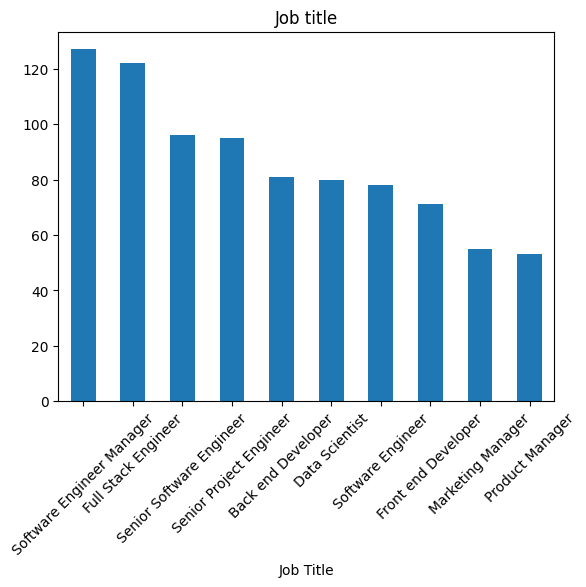

In [15]:
# let show top 10 titles
top10 = var['Job Title'].value_counts().head(10).plot(kind='bar')
plt.title("Job title")
plt.xticks(rotation=45)
plt.show()

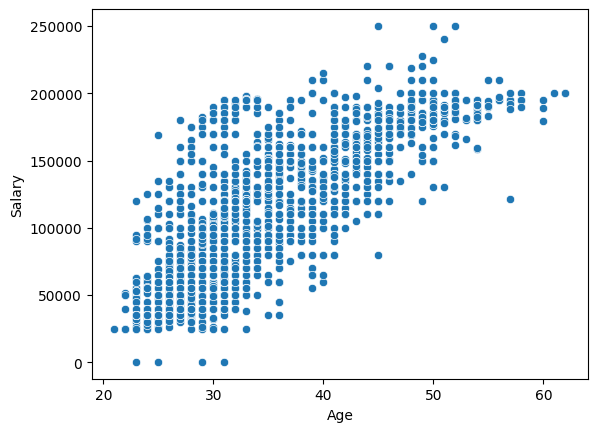

In [16]:
# Relationship between age and salary
sns.scatterplot(x='Age',y='Salary',data=var)
plt.show()

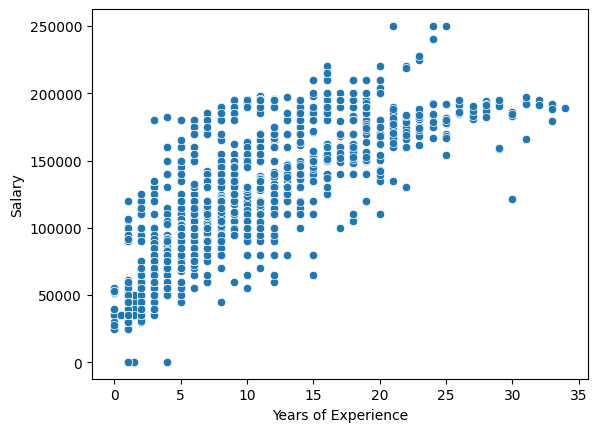

In [17]:
# salary vs experience
sns.scatterplot(x='Years of Experience',y='Salary',data=var)
plt.show()

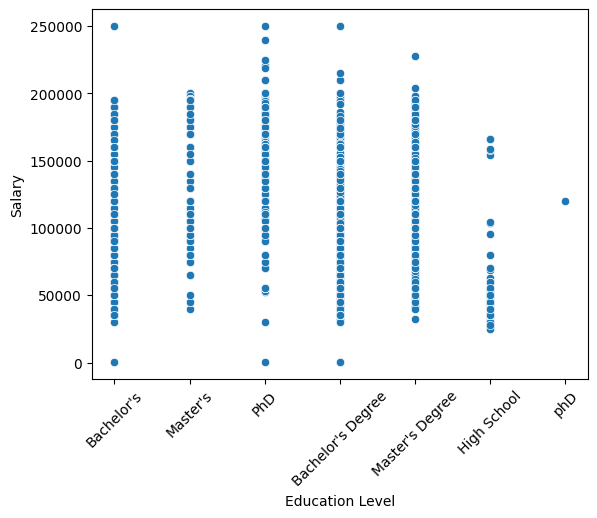

In [18]:
#education vs salary
sns.scatterplot(x='Education Level',y='Salary',data=var)
plt.xticks(rotation=45)
plt.show()

# Feature Engineering

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X = var[['Age',
        'Years of Experience',
        'Job Title',
        'Education Level',
        'Gender']]
y = var['Salary']

In [22]:
# splitting of data
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [23]:
X_train.shape

(1430, 5)

In [24]:
X_train.head()

,Age,Years of Experience,Job Title,Education Level,Gender
6480,45.0,15.0,Director of Marketing,Master's Degree,Male
176,42.0,18.0,Senior Marketing Manager,PhD,Female
6018,29.0,5.0,Financial Analyst,Master's Degree,Male
3892,28.0,4.0,Human Resources Coordinator,Bachelor's Degree,Female
1231,49.0,15.0,Senior Project Engineer,PhD,Male


In [25]:
y_train.head()

6480    150000.0
176     140000.0
6018     95000.0
3892     60000.0
1231    185000.0
Name: Salary, dtype: float64

## There are categorical columns too in data,for building a perfect model we have to convert them into numeric

In [26]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [27]:
categorical_cols = ['Job Title', 'Education Level', 'Gender']
numeric_cols = ['Age', 'Years of Experience']

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

## Random Forest Regressor

In [29]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

## Apply pipeline too

In [30]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [31]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [32]:
#pipeline preductions
y_pred = pipeline.predict(X_test)

In [33]:
y_pred[:10]

array([ 61184.16666667, 107219.65511905, 178240.655     ,  20052.5       ,
        27838.33333333, 123536.80291667,  96966.66025974, 148576.64333333,
       125922.22      , 137475.        ])

## For checking if model work better we predict actual vs predicted

In [34]:
comparison = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

comparison.head(10)

,Actual Salary,Predicted Salary
0,65000.0,61184.166667
1,100000.0,107219.655119
2,180000.0,178240.655000
3,50000.0,20052.500000
4,25000.0,27838.333333
5,140000.0,123536.802917
6,100000.0,96966.660260
7,100000.0,148576.643333
8,145000.0,125922.220000
9,135000.0,137475.000000


## Model Evaluation

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 10381.275347536113


In [37]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 15549.149516622769


In [38]:
r2 = r2_score(y_test, y_pred)
print("R²:", r2)

R²: 0.9115840166381887


In [51]:
# new person included to check model accuracy
new_person = pd.DataFrame({
    'Age': [30],
    'Years of Experience': [5],
    'Job Title': ['Data Scientist'],
    'Education Level': ["Master's"],
    'Gender': ['Female']
})

In [40]:
predicted_salary = pipeline.predict(new_person)

print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 165655.0


In [42]:
var['Salary'].describe()

count      1788.000000
mean     113177.285794
std       51583.040514
min         350.000000
25%       70000.000000
50%      110000.000000
75%      160000.000000
max      250000.000000
Name: Salary, dtype: float64

## Let check for training and testing score

In [44]:
train_pred = pipeline.predict(X_train)

print("Training R²:", r2_score(y_train, train_pred))
print("Testing R²:", r2_score(y_test, y_pred))

Training R²: 0.9850727137445804
Testing R²: 0.9115840166381887


## Ohh, time to save model 

In [45]:
import joblib

joblib.dump(pipeline, "salary_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [46]:
loaded_model = joblib.load("salary_prediction_model.pkl")

# Finally end